# 1. Mengumpulkan dan menganalisis berbagai permasalahan, kemudian menentukan satu solusi utama yang akan dikembangkan dalam proyek.

Dalam kehidupan sehari-hari, banyak pelajar dan remaja seringkali tidak menyadari ke mana sebagian besar uang mereka digunakan dan kesulitan mengontrol pengeluaran hingga batas tertentu. Beberapa permasalahan utama yang diidentifikasi:

1. Kurangnya literasi keuangan sejak dini: Tidak ada sistem analisis dan prediksi berbasis data yang membantu pengambilan keputusan finansial.
2. Fitur keuangan yang terbatas: Aplikasi yang ada umumnya hanya berfokus pada pencatatan transaksi saja, tanpa analisis mendalam.
3. Transaksi tidak tercatat dengan baik: Terlalu banyak transaksi yang tidak tercatat seperti jajan, shopping, dan pembayaran tunai sehari-hari.
4. Minimnya pemantauan orang tua: Tidak ada fitur yang memudahkan irang tua memantau penggunaan uang saku digital anak.

**Solusi yang dikembangkan**:
**PAYBAE (Pay-Balance-Easy)** merupakan aplikasi yang menintegrasikan dompet digital dengan sistem analisis keuangan berbasis AI, yang dapat melakukan berbagai hal sebagai berikut:
- Mencatat dan mengkategorikan transaksi.
- Menganalisis pola pengeluaran pengguna berdasarkan riwayat transaksi.
- Memberikan prediksi pengeluaran dan forecast tabungan ke depan.
- Menyediakan rekomendasi hemat yang personal berbasis AI.
- Memberikan fitur pemantauan orang tua terhadap penggunaan uang saku digital.

# 2. "Melakukan proses Data Wrangling secara end-to-end, yang mencakup:
- Gathering Data: Mengumpulkan data atau mencari dataset yang relevan, baik dari sumber publik maupun melalui proses scraping.
- Assessing Data: Mengevaluasi kualitas dan struktur data.
- Cleaning Data: Membersihkan dan mempersiapkan data sebelum masuk ke tahap analisis."

## Load Library


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## Load Dataset


In [51]:
# Input dataset
df = pd.read_csv('dataset_paybae.csv')
df.head()

,Date,title,category,amount,type,id
0,2014-01-01 09:00:00,Kiriman Orang Tua,NaN,2500000.0,INCOME,b6a567c9-30e9-44a7-b5eb-59cd44590256
1,2014-01-01 17:00:00,Bensin,Transport,20000.0,EXPENSE,35eff235-d2da-4799-9c22-9ec2bef7555f
2,2014-01-01 12:30:00,Pecel Lele,NaN,13950.0,EXPENSE,22de6c60-5eeb-49c0-a91f-aa00fed9b8be
3,2014-01-01 19:00:00,Ayam Geprek,Food & Drinks,17050.0,EXPENSE,bc1b63b4-7952-4378-9c5e-72ee409d9254
4,2014-01-02 12:30:00,Ayam Geprek,Food & Drinks,14400.0,EXPENSE,d3f36f7f-00f1-4e3d-b2ef-c680c1f83696


## Assessing Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      9546 non-null   object 
 1   title     9546 non-null   object 
 2   category  8618 non-null   object 
 3   amount    9546 non-null   float64
 4   type      9546 non-null   object 
 5   id        9546 non-null   object 
dtypes: float64(1), object(5)
memory usage: 447.6+ KB


In [50]:
# Cek missing value / data hilang
df.isna().sum()

,0
Date,0
deskripsi,0
kategori,0
nominal,0
tipe,0
is_outlier,0
tahun_bulan,0
hari,0


In [49]:
# Cek apakah ada data yang duplikat
df.duplicated().sum()

np.int64(0)

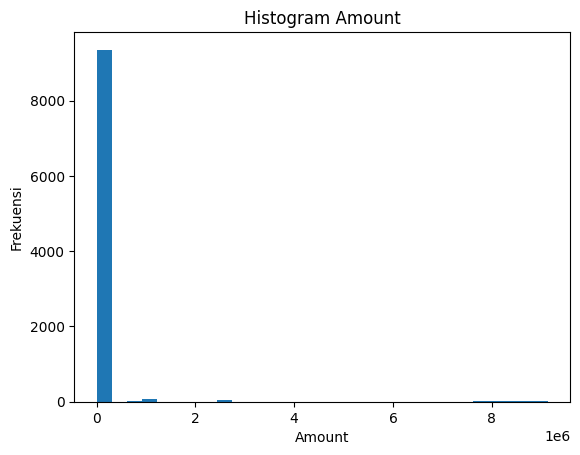

In [8]:
# Cek distribusi data
plt.figure()
plt.hist(df['amount'], bins=30)

plt.title("Histogram Amount")
plt.xlabel("Amount")
plt.ylabel("Frekuensi")

plt.show()

## Cleaning Data

In [9]:
# Mengubah format tipe data date menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      9546 non-null   datetime64[ns]
 1   title     9546 non-null   object        
 2   category  8618 non-null   object        
 3   amount    9546 non-null   float64       
 4   type      9546 non-null   object        
 5   id        9546 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 447.6+ KB


In [10]:
# Drop kolom yang tidak digunakan

df = df.drop(columns=['id'])

In [11]:
# Melihat di baris berapa missing value berada

pd.set_option('display.max_rows', None)
df[df['category'].isnull()]

,Date,title,category,amount,type
0,2014-01-01 09:00:00,Kiriman Orang Tua,NaN,2.500000e+06,INCOME
2,2014-01-01 12:30:00,Pecel Lele,NaN,1.395000e+04,EXPENSE
27,2014-01-11 12:30:00,Nasi Telur,NaN,1.260000e+04,EXPENSE
34,2014-01-13 19:00:00,Pecel Lele,NaN,1.265000e+04,EXPENSE
38,2014-01-15 12:30:00,Pecel Lele,NaN,1.035000e+04,EXPENSE
42,2014-01-16 19:00:00,Nasi Campur,NaN,1.705000e+04,EXPENSE
53,2014-01-21 12:30:00,Soto,NaN,1.035000e+04,EXPENSE
59,2014-01-23 19:00:00,Ayam Geprek,NaN,1.815000e+04,EXPENSE
79,2014-01-31 19:00:00,Pecel Lele,NaN,1.430000e+04,EXPENSE
85,2014-02-02 19:00:00,Soto,NaN,1.760000e+04,EXPENSE


In [12]:
# Mengisi category berdasarkan title
df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Minuman|Warteg|Nasi|Bubur|Gorengan|GoFood|ShopeeFood|Mie|Cemilan|Jajan|Pecel|Sarapan|Makan|Ayam|Roti|Es|Kopi|Soto|Teh|Bakso|Snack|Warmindo|Lontong', case=False, na=False)),
    'category'
] = 'Food & Drinks'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Parkir|Bensin|Bus|Gojek|motor|KRL|TransJakarta|BBM|Pertamax|Grab|oli|Servis', case=False, na=False)),
    'category'
] = 'Transport'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Shopee|Tokopedia|Belanja', case=False, na=False)),
    'category'
] = 'Shopping'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Pulsa|Bayar Kos|Netflix|Spotify|Tagihan|Air|Listrik', case=False, na=False)),
    'category'
] = 'Bills & Fees'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Kiriman', case=False, na=False)),
    'category'
] = 'Family Transfer'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Gaji', case=False, na=False)),
    'category'
] = 'Salary'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Buku|Print|Fotokopi|Iuran|ATK|Alat', case=False, na=False)),
    'category'
] = 'Education'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Obat|Minyak Kayu Putih|Masker|Panadol|Paracetamol|Antangin|Vitamin|Plester', case=False, na=False)),
    'category'
] = 'Health'

df.loc[
    (df['category'].isnull()) & (df['title'].str.contains('Laundry|Kebutuhan|Detergen', case=False, na=False)),
    'category'
] = 'Needs'

In [52]:
# Cek kembali apakah masih terdapat missing value / data hilang
df.isna().sum()

,0
Date,0
title,0
category,928
amount,0
type,0
id,0


In [14]:
# Cek Outlier pada Amount
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (df['amount'] < lower) | (df['amount'] > upper)
print(f"\nJumlah outlier Amount: {outlier_mask.sum()}")
print(df[outlier_mask][['Date', 'amount', 'category', 'type']].to_string())


Jumlah outlier Amount: 442
                    Date        amount         category     type
0    2014-01-01 09:00:00  2.500000e+06  Family Transfer   INCOME
11   2014-01-05 11:00:00  5.000000e+04     Bills & Fees  EXPENSE
37   2014-01-15 19:30:00  1.000000e+05            Needs  EXPENSE
80   2014-02-01 09:00:00  2.500000e+06           Income   INCOME
91   2014-02-05 11:00:00  5.000000e+04     Bills & Fees  EXPENSE
116  2014-02-15 19:30:00  1.000000e+05            Needs  EXPENSE
152  2014-03-01 09:00:00  2.500000e+06           Income   INCOME
163  2014-03-05 11:00:00  5.000000e+04     Bills & Fees  EXPENSE
190  2014-03-15 19:30:00  1.000000e+05            Needs  EXPENSE
233  2014-04-01 09:00:00  2.500000e+06           Income   INCOME
244  2014-04-05 11:00:00  5.000000e+04     Bills & Fees  EXPENSE
271  2014-04-15 19:30:00  1.000000e+05            Needs  EXPENSE
311  2014-05-01 09:00:00  2.500000e+06           Income   INCOME
323  2014-05-05 11:00:00  5.000000e+04     Bills & Fees  EXPEN

In [15]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['is_outlier'] = (df['amount'] < lower) | (df['amount'] > upper)

In [16]:
# Rename variabel menjadi bahasa
df.rename(columns={'title': 'deskripsi'}, inplace=True)
df.rename(columns={'category': 'kategori'}, inplace=True)
df.rename(columns={'amount': 'nominal'}, inplace=True)
df.rename(columns={'type': 'tipe'}, inplace=True)

# Rename isi category menjadi bahasa
df['kategori'] = df['kategori'].replace({
    'Food & Drinks' : 'Makanan & Minuman',
    'Transport' : 'Transportasi',
    'Shopping' : 'Belanja',
    'Bills & Fees' : 'Tagihan',
    'Family Transfer' : 'Kiriman Orang Tua',
    'Education' : 'Pendidikan',
    'Health' : 'Kesehatan',
    'Needs' : 'Kebutuhan',
    'Salary' : 'Gaji'
})

# Rename isi tipe menjadi bahasa
df['tipe'] = df['tipe'].replace({
    'INCOME' : 'Pemasukan',
    'EXPENSE' : 'Pengeluaran'
})

df.head()

,Date,deskripsi,kategori,nominal,tipe,is_outlier
0,2014-01-01 09:00:00,Kiriman Orang Tua,Kiriman Orang Tua,2500000.0,Pemasukan,True
1,2014-01-01 17:00:00,Bensin,Transportasi,20000.0,Pengeluaran,False
2,2014-01-01 12:30:00,Pecel Lele,Makanan & Minuman,13950.0,Pengeluaran,False
3,2014-01-01 19:00:00,Ayam Geprek,Makanan & Minuman,17050.0,Pengeluaran,False
4,2014-01-02 12:30:00,Ayam Geprek,Makanan & Minuman,14400.0,Pengeluaran,False


In [17]:
# Simpan dataset bersih
df.to_csv('dataset_paybae_clean.csv', index=False)

# 3. Mendefinisikan pertanyaan bisnis yang dapat diukur.

Pertanyaan 1: "Bagaimana distribusi dan pola pengeluaran pengguna berdasarkan kategori dan waktu transaksi selama periode 2014-2023?"

Pertanyaan 2: "Bagaimana tren arus kas pengguna berdasarkan pemasukan dan pengeluaran selama periode 2014-2023?"

Pertantaan 3: "Kategori pengeluaran apa yang mengalami perubahan dan fluktuasi terbesar selama periode 2014-2023?"

# 4. Melakukan Exploratory Data Analysis (EDA) untuk mendapatkan insight dari data.

In [18]:
# total Pemasukan atau pengeluaran
df.groupby('tipe')['nominal'].sum()

,nominal
tipe,
Pemasukan,7.370500e+08
Pengeluaran,2.803508e+08


In [19]:
# pengeluaran per kategori
pengeluaran = df[df['tipe'] == 'Pengeluaran']
pengeluaran.groupby('kategori')['nominal'].sum().sort_values(ascending=False)

,nominal
kategori,
Makanan & Minuman,1.482836e+08
Tagihan,7.676875e+07
Transportasi,2.792541e+07
Kebutuhan,2.421515e+07
Belanja,1.666294e+06
Kesehatan,1.491543e+06


In [20]:
# Distribusi kategori
df['kategori'].value_counts()

,count
kategori,
Makanan & Minuman,7304
Transportasi,1218
Kebutuhan,633
Tagihan,192
Income,111
Kesehatan,64
Belanja,15
Gaji,7
Kiriman Orang Tua,2


In [21]:
# Tren bulanan
df.groupby(df['Date'].dt.to_period('M'))['nominal'].sum()

,nominal
Date,
2014-01,3.832000e+06
2014-02,3.702000e+06
2014-03,3.848000e+06
2014-04,3.865000e+06
2014-05,3.884000e+06
2014-06,3.850000e+06
2014-07,3.832000e+06
2014-08,3.860000e+06
2014-09,3.753000e+06


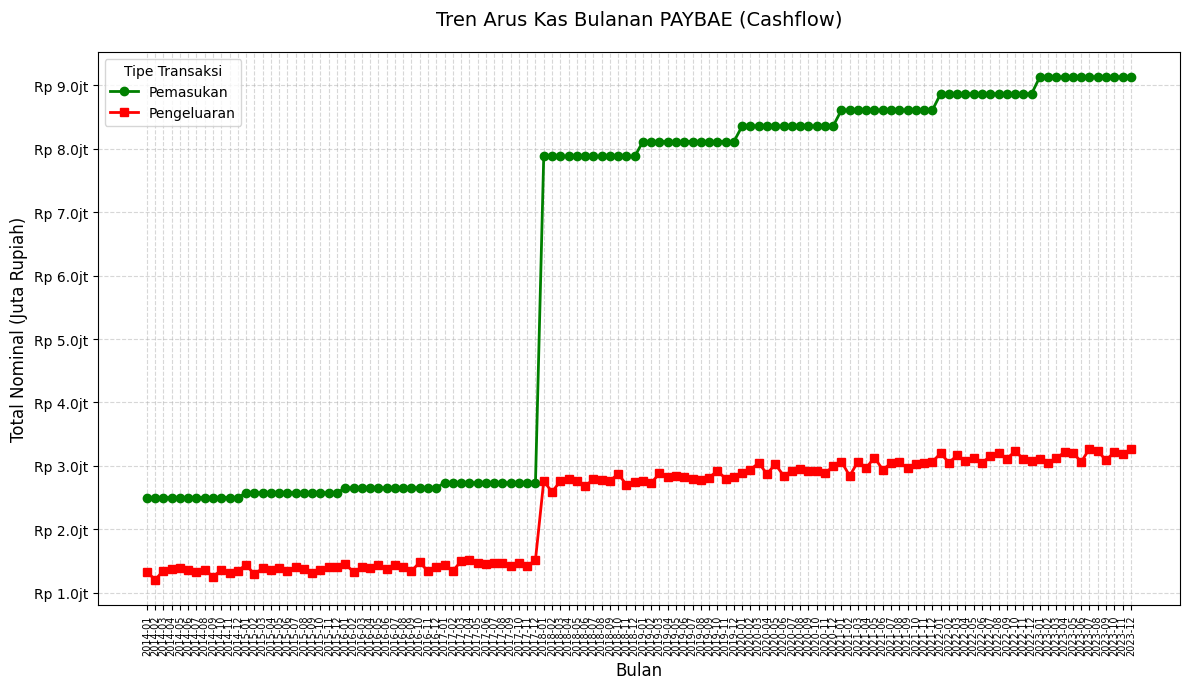

In [22]:
# Grafik tren pemasukan dan pengeluaran
df['tahun_bulan'] = df['Date'].dt.to_period('M')
tren = df.groupby(['tahun_bulan', 'tipe'])['nominal'].sum().unstack().fillna(0)
tren.index = tren.index.astype(str)

plt.figure(figsize=(12, 7))

# Plot Pemasukan dan Pengeluaran dengan warna yang kontras
plt.plot(tren.index, tren['Pemasukan'], marker='o', linewidth=2, label='Pemasukan', color='green')
plt.plot(tren.index, tren['Pengeluaran'], marker='s', linewidth=2, label='Pengeluaran', color='red')

# Format angka di sumbu Y agar menjadi "Juta" (biar tidak kepanjangan nol-nya)
def jutaan(x, pos):
    return f'Rp {x*1e-6:,.1f}jt' # M untuk Juta (Million) atau bisa ganti 'Jt'
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(jutaan))

plt.title("Tren Arus Kas Bulanan PAYBAE (Cashflow)", fontsize=14, pad=20)
plt.xlabel("Bulan", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("Total Nominal (Juta Rupiah)", fontsize=12)
plt.legend(title="Tipe Transaksi")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

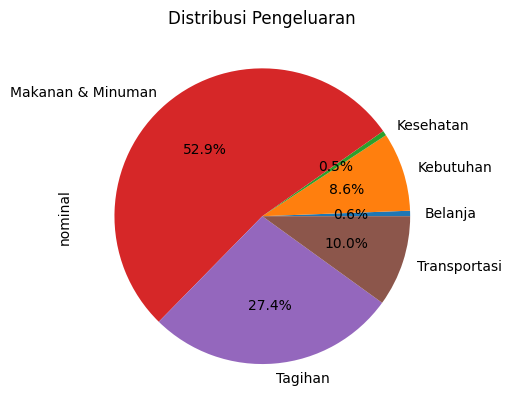

In [23]:
# visualisasi pie chart
pengeluaran.groupby('kategori')['nominal'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribusi Pengeluaran")
plt.show()

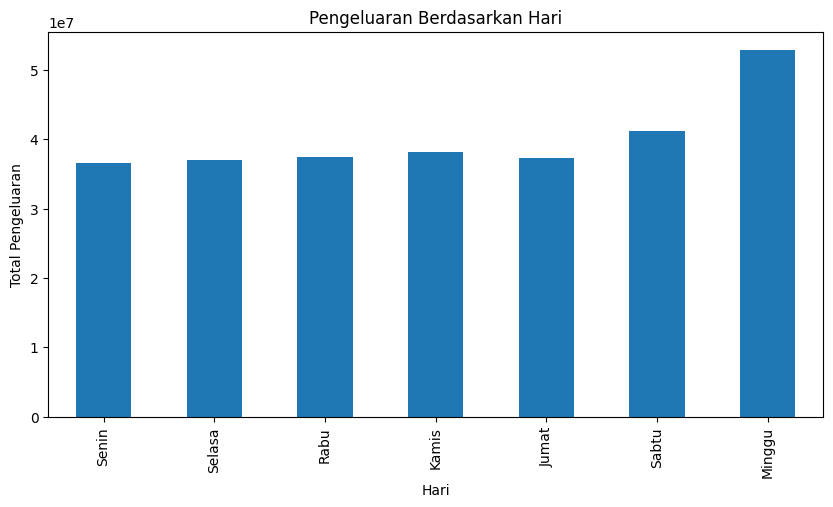

In [24]:
# ambil pengeluaran saja
pengeluaran = df[df['tipe'] == 'Pengeluaran'].copy()

# buat nama hari bahasa Inggris dulu
pengeluaran['hari'] = pengeluaran['Date'].dt.day_name()

# mapping ke bahasa
mapping_hari = {
    'Monday': 'Senin',
    'Tuesday': 'Selasa',
    'Wednesday': 'Rabu',
    'Thursday': 'Kamis',
    'Friday': 'Jumat',
    'Saturday': 'Sabtu',
    'Sunday': 'Minggu'
}

pengeluaran['hari'] = pengeluaran['hari'].map(mapping_hari)

# urutan hari
urutan_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

# grouping
pengeluaran_mingguan = pengeluaran.groupby('hari')['nominal'].sum()

# urutkan
pengeluaran_mingguan = pengeluaran_mingguan.reindex(urutan_hari)

# plot
pengeluaran_mingguan.plot(kind='bar', figsize=(10,5))

plt.title("Pengeluaran Berdasarkan Hari")
plt.xlabel("Hari")
plt.ylabel("Total Pengeluaran")
plt.show()

In [25]:
# waktu paling boros
df['hari'] = df['Date'].dt.day_name()
df.groupby('hari')['nominal'].sum().sort_values(ascending=False)

,nominal
hari,
Sunday,1.556563e+08
Wednesday,1.529524e+08
Friday,1.495300e+08
Saturday,1.445641e+08
Tuesday,1.403455e+08
Thursday,1.379790e+08
Monday,1.363735e+08


# 5. Membuat visualisasi data dan melakukan explanatory analysis untuk menjawab pertanyaan bisnis.

In [26]:
# Persiapan ulang data
pengeluaran = df[df['tipe'] == 'Pengeluaran'].copy()

print(f"Total transaksi pengeluaran: {len(pengeluaran):,}")
print(f"Kategori: {pengeluaran['kategori'].unique().tolist()}")

Total transaksi pengeluaran: 9,426
Kategori: ['Transportasi', 'Makanan & Minuman', 'Tagihan', 'Kebutuhan', 'Kesehatan', 'Belanja']


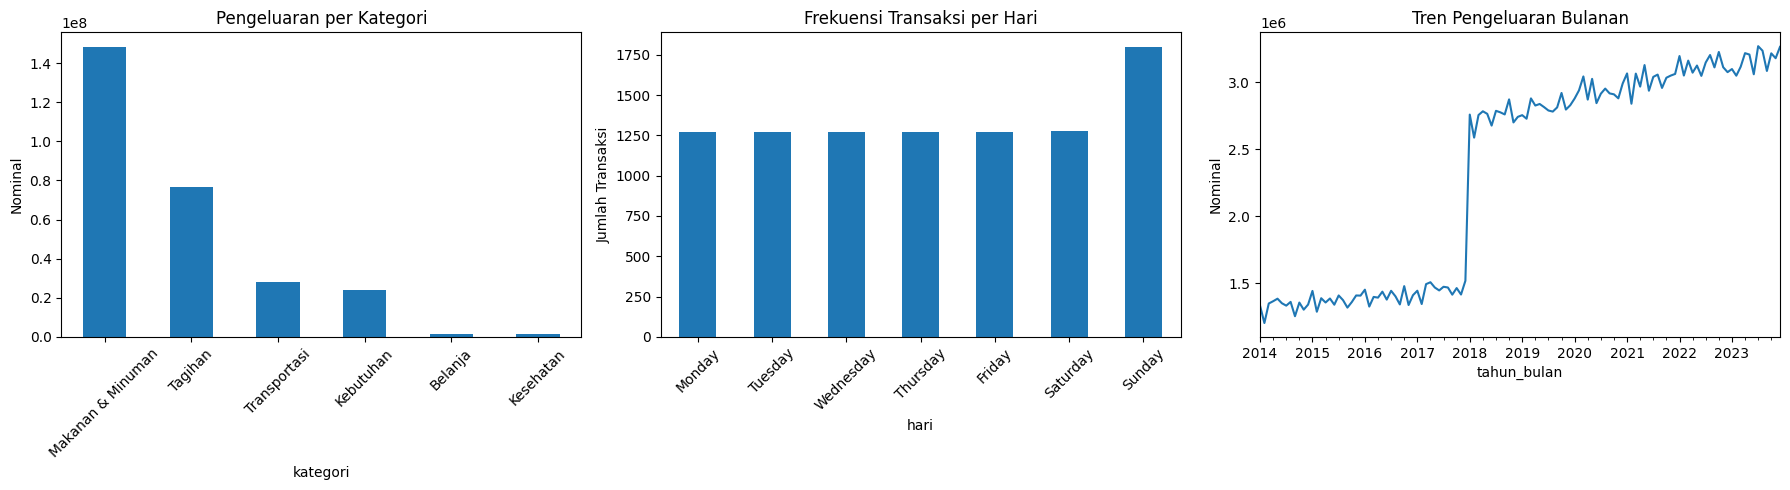

In [44]:
'''
PERTANYAAN 1:
Bagaimana distribusi dan pola pengeluaran pengguna
berdasarkan kategori dan waktu transaksi selama
periode 2014-2023?
'''
# Data
pengeluaran = df[df['tipe'] == 'Pengeluaran']
pengeluaran_kategori = (pengeluaran.groupby('kategori')['nominal'].sum().sort_values(ascending=False))
hari_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
frekuensi_hari = (pengeluaran['hari'].value_counts().reindex(hari_order))
pengeluaran_bulanan = (pengeluaran.groupby('tahun_bulan')['nominal'].sum())

# Membuat 1 baris 3 kolom
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafik 1
pengeluaran_kategori.plot(kind='bar', ax=axes[0])
axes[0].set_title('Pengeluaran per Kategori')
axes[0].set_ylabel('Nominal')
axes[0].tick_params(axis='x', rotation=45)

# Grafik 2
frekuensi_hari.plot(kind='bar', ax=axes[1])
axes[1].set_title('Frekuensi Transaksi per Hari')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].tick_params(axis='x', rotation=45)

# Grafik 3
pengeluaran_bulanan.plot(ax=axes[2])
axes[2].set_title('Tren Pengeluaran Bulanan')
axes[2].set_ylabel('Nominal')

plt.tight_layout()
plt.show()

Berdasarkan grafik tersebut dapat disimpulkan:

- Berdasarkan grafik pertama dapat disimpulkan bahwa pengeluaran terbesar berasal dari kategori Makanan & Minuman, diikuti oleh Tagihan di urutan kedua. Hal ini menunjukkan bahwa sebagian besar uang dihabiskan untuk kebutuhan pokok sehari-hari yang memang tidak bisa dihindari. Sementara itu kategori Belanja dan Kesehatan memiliki porsi yang sangat kecil, yang mencerminkan gaya hidup yang cukup hemat dan tidak banyak pengeluaran di luar kebutuhan utama.

- Berdasarkan grafik kedua dapat disimpulkan bahwa frekuensi transaksi dari hari Senin hingga Sabtu relatif sama dan stabil. Namun pada hari Minggu terjadi lonjakan yang cukup signifikan dibandingkan hari-hari lainnya. Hal ini mengindikasikan adanya kebiasaan berbelanja atau melakukan lebih banyak transaksi di hari Minggu, kemungkinan untuk memenuhi kebutuhan mingguan atau aktivitas di akhir pekan.

- Berdasarkan grafik ketiga dapat disimpulkan bahwa tren pengeluaran bulanan mengalami kenaikan yang cukup konsisten dari tahun 2014 hingga 2023. Yang paling mencolok adalah lonjakan tajam yang terjadi di awal tahun 2018, di mana pengeluaran hampir dua kali lipat dalam waktu singkat. Setelah itu pengeluaran terus meningkat secara bertahap hingga akhir periode, yang mencerminkan dampak nyata dari kenaikan harga dan perubahan pola hidup dari tahun ke tahun.

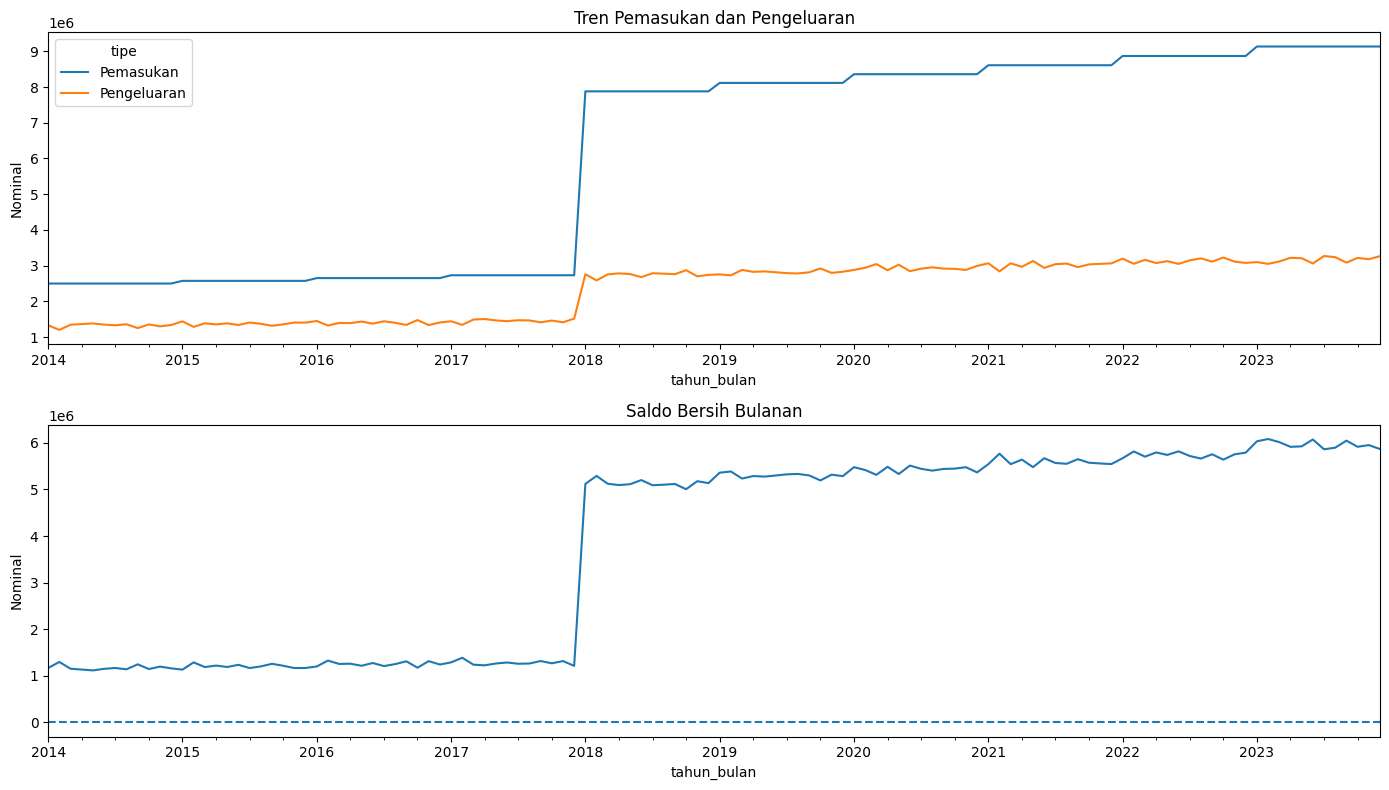

In [45]:
'''
PERTANYAAN 2:
Bagaimana tren arus kas pengguna berdasarkan
pemasukan dan pengeluaran selama periode 2014-2023?
'''

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Grafik pemasukan dan pengeluaran
cashflow[['Pemasukan','Pengeluaran']].plot(ax=axes[0])
axes[0].set_title('Tren Pemasukan dan Pengeluaran')
axes[0].set_ylabel('Nominal')

# Grafik saldo bersih
cashflow['saldo_bersih'].plot(ax=axes[1])
axes[1].axhline(0, linestyle='--')
axes[1].set_title('Saldo Bersih Bulanan')
axes[1].set_ylabel('Nominal')

plt.tight_layout()
plt.show()

Berdasarkan grafik tersebut dapat disimpulkan:

- Berdasarkan grafik pertama dapat disimpulkan bahwa pemasukan selalu lebih besar dari pengeluaran di sepanjang periode 2014–2023. Sebelum 2018 pemasukan berada di sekitar Rp 2,5 juta per bulan sementara pengeluaran sekitar Rp 1,3 juta. Kemudian di awal 2018 pemasukan naik signifikan ke sekitar Rp 8 juta dan terus tumbuh hingga Rp 9 juta di 2023. Pengeluaran pun ikut naik dari Rp 1,4 juta menjadi sekitar Rp 3,2 juta, namun kenaikannya jauh lebih kecil dibandingkan kenaikan pemasukan.

- Berdasarkan grafik kedua dapat disimpulkan bahwa saldo bersih selalu berada di atas nol sepanjang 2014 hingga 2023, yang artinya tidak pernah ada bulan yang defisit. Dari 2014 hingga 2017 saldo bulanan stabil di sekitar Rp 1,2 juta. Kemudian di awal 2018 terjadi lonjakan drastis ke sekitar Rp 5,2 juta dan terus meningkat hingga mendekati Rp 6 juta di 2023. Hal ini menunjukkan bahwa kondisi keuangan semakin membaik dari tahun ke tahun.

/tmp/ipykernel_401/3814417351.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pengeluaran['tahun'] = pd.to_datetime(pengeluaran['Date']).dt.year


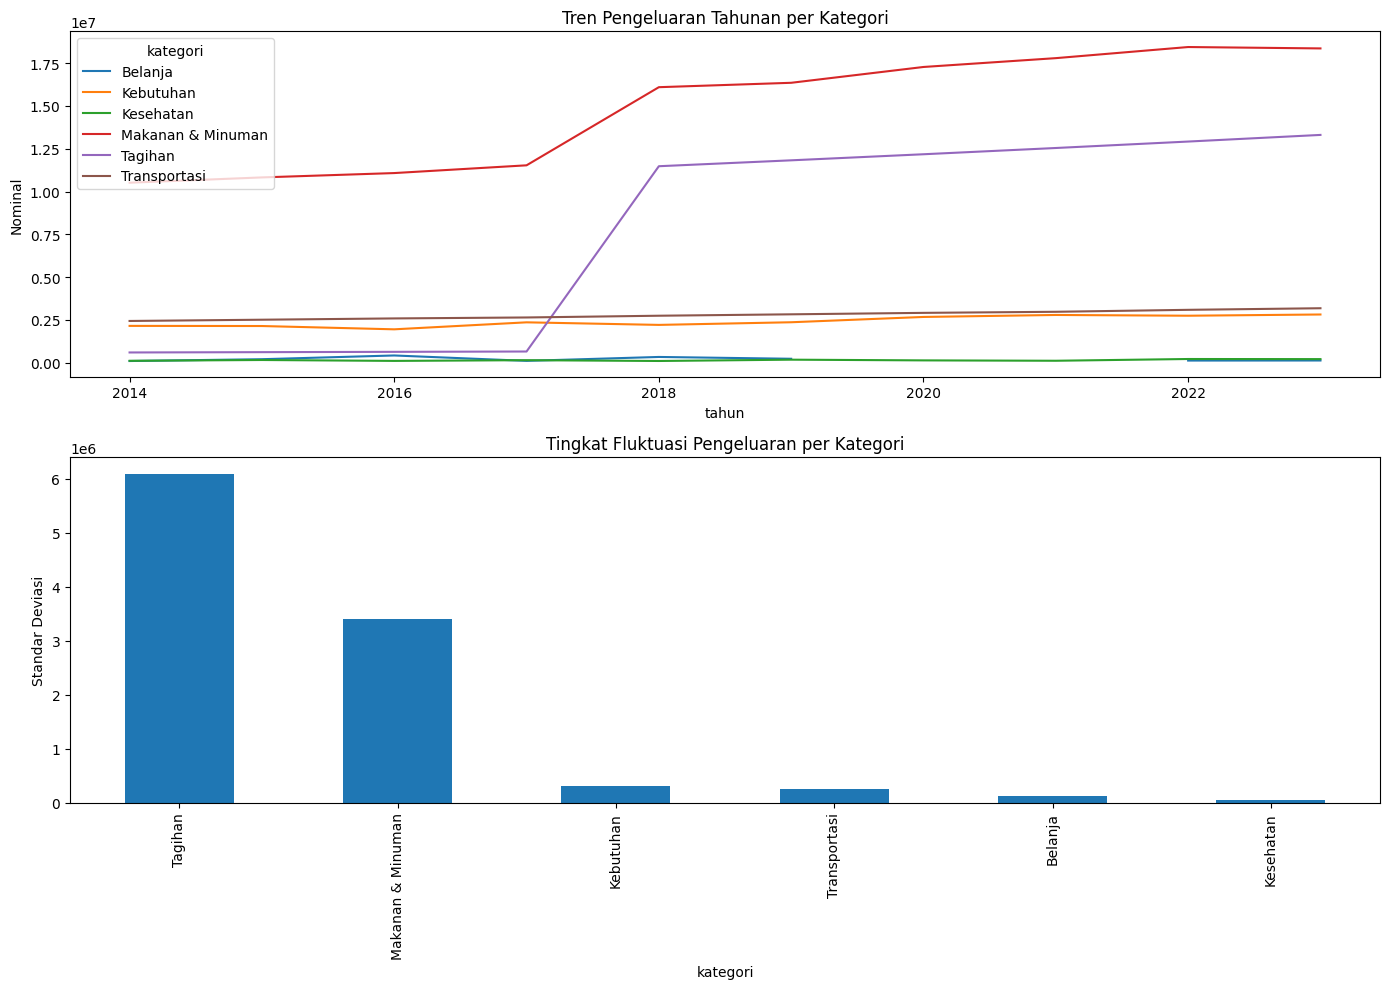

In [47]:
'''
PERTANYAAN 3:
Kategori pengeluaran apa yang mengalami perubahan
dan fluktuasi terbesar selama periode 2014-2023?
'''

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Tren tahunan per kategori
pengeluaran['tahun'] = pd.to_datetime(pengeluaran['Date']).dt.year
tren_kategori = (pengeluaran.groupby(['tahun','kategori'])['nominal'].sum().unstack())
tren_kategori.plot(ax=axes[0])
axes[0].set_title('Tren Pengeluaran Tahunan per Kategori')
axes[0].set_ylabel('Nominal')

# Mengukur fluktuasi kategori
fluktuasi = (tren_kategori.std().sort_values(ascending=False))
fluktuasi.plot(kind='bar', ax=axes[1])
axes[1].set_title('Tingkat Fluktuasi Pengeluaran per Kategori')
axes[1].set_ylabel('Standar Deviasi')
plt.tight_layout()
plt.show()

Berdasarkan grafik tersebut dapat disimpulkan bahwa:

- Berdasarkan grafik pertama dapat disimpulkan bahwa Makanan & Minuman secara konsisten menjadi kategori pengeluaran terbesar sepanjang 2014 hingga 2023 dan terus meningkat setiap tahunnya dari sekitar Rp 10,5 juta menjadi hampir Rp 19 juta. Yang menarik adalah kategori Tagihan yang sebelum 2018 hampir tidak terlihat di grafik, tiba-tiba melonjak drastis di tahun 2018 dan terus naik hingga menjadi kategori terbesar kedua di angka Rp 13 juta. Sementara kategori lain seperti Kebutuhan, Transportasi, Belanja, dan Kesehatan tumbuh sangat lambat dan nilainya jauh di bawah dua kategori utama tersebut.

- Berdasarkan grafik kedua dapat disimpulkan bahwa Tagihan adalah kategori yang paling fluktuatif dengan standar deviasi tertinggi mencapai sekitar Rp 6 juta, diikuti oleh Makanan & Minuman di angka sekitar Rp 3,4 juta. Tingginya fluktuasi pada Tagihan sangat masuk akal mengingat lonjakan besar yang terjadi di 2018 seperti yang terlihat di grafik pertama. Sementara kategori Kebutuhan, Transportasi, Belanja, dan Kesehatan memiliki fluktuasi yang sangat kecil, yang menunjukkan bahwa pengeluaran di kategori-kategori tersebut cenderung stabil dan terprediksi dari tahun ke tahun.

# 6. Mengembangkan dashboard interaktif menggunakan Streamlit untuk menampilkan insight dan kesimpulan.

In [1]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import datetime

# 1. KONFIGURASI HALAMAN & THEME PROFESSIONAL
st.set_page_config(page_title="PAYBAE AI Analytics Dashboard", page_icon="💳", layout="wide")

# Custom CSS untuk UI/UX Dashboard yang Clean
st.markdown("""
<style>

div[data-testid="metric-container"] {
    background-color: var(--secondary-background-color);
    border: 1px solid rgba(128,128,128,0.2);
    padding: 20px;
    border-radius: 12px;
}

.business-card {
    background-color: var(--secondary-background-color);
    color: var(--text-color);
    padding: 20px;
    border-radius: 10px;
    border: 1px solid rgba(128,128,128,0.2);
    border-left: 6px solid #228be6;
    margin-bottom: 20px;
}

.business-card h4,
.business-card p,
.business-card b,
.business-card code {
    color: var(--text-color);
}

.ai-tag {
    background-color: #e7f5ff;
    color: #1c7ed6;
    padding: 4px 8px;
    border-radius: 4px;
    font-size: 12px;
    font-weight: bold;
}

</style>
""", unsafe_allow_html=True)

# 2. DATA PIPELINE (LOAD & WRANGLING)
@st.cache_data
def load_financial_data():
    # Membaca dataset utama hasil tracking
    df = pd.read_csv('dataset_paybae_clean.csv')
    df['Date'] = pd.to_datetime(df['Date'])

    # Standardisasi nama kolom sesuai kebutuhan dashboard
    df.rename(columns={'amount': 'nominal', 'type': 'tipe', 'category': 'kategori'}, inplace=True)
    df['tipe'] = df['tipe'].replace({'INCOME': 'Pemasukan', 'EXPENSE': 'Pengeluaran'})

    # Mengisi missing value pada kategori secara logis
    df['kategori'] = df['kategori'].fillna('Lain-lain / Belum Dikategorikan')

    # Fitur Ekstraksi Waktu
    df['Tahun'] = df['Date'].dt.year
    df['Bulan-Tahun'] = df['Date'].dt.to_period('M').astype(str)
    df['Hari_ke'] = df['Date'].dt.day
    df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)

    return df

try:
    df = load_financial_data()
except FileNotFoundError:
    st.error("❌ File 'dataset_paybae.csv' tidak ditemukan. Pastikan file berada di folder yang sama.")
    st.stop()

# 3. HEADER UTAMA INTERAKTIF
st.title("💳 PAYBAE Advanced Financial Intelligence Dashboard")
st.markdown("### *Analisis Deskriptif Historis & Pemetaan Strategis Pondasi Model AI*")
st.write("Platform manajemen finansial cerdas bagi masyarakat untuk mendeteksi anomali, memprediksi cashflow, dan memberikan rekomendasi anggaran.")

# 4. SIDEBAR KONTROL (SESUAI REQUEST GAMBAR 1)
st.sidebar.header("⚙️ Kontrol & Filter Data")

# --- Fitur 1: Rentang Tanggal ---
st.sidebar.markdown("**Rentang Waktu**")
min_date = df['Date'].min().date()
max_date = df['Date'].max().date()
date_range = st.sidebar.date_input(
    "Pilih Rentang Waktu:",
    value=(min_date, max_date),
    min_value=min_date,
    max_value=max_date,
    label_visibility="collapsed"
)

if len(date_range) == 2:
    start_date, end_date = date_range
    df_filtered = df[(df['Date'].dt.date >= start_date) & (df['Date'].dt.date <= end_date)]
else:
    df_filtered = df

# --- Fitur 2: Filter Kategori Pengeluaran ---
list_kategori = df[df['tipe'] == 'Pengeluaran']['kategori'].unique().tolist()
selected_kategori = st.sidebar.multiselect(
    "Filter Kategori Pengeluaran",
    options=list_kategori,
    default=list_kategori
)
# Terapkan filter kategori (hanya memfilter pengeluaran, pemasukan tetap masuk)
df_filtered = df_filtered[(df_filtered['kategori'].isin(selected_kategori)) | (df_filtered['tipe'] == 'Pemasukan')]


# --- Fitur 3: Filter Hari (Semua, Weekday, Weekend) ---
filter_hari = st.sidebar.radio(
    "Filter Hari",
    options=["Semua", "Weekday (Senin-Jumat)", "Weekend (Sabtu-Minggu)"]
)
if filter_hari == "Weekday (Senin-Jumat)":
    df_filtered = df_filtered[df_filtered['Is_Weekend'] == 0]
elif filter_hari == "Weekend (Sabtu-Minggu)":
    df_filtered = df_filtered[df_filtered['Is_Weekend'] == 1]


# 5. KARTU METRIK UTAMA
total_pemasukan = df_filtered[df_filtered['tipe'] == 'Pemasukan']['nominal'].sum()
total_pengeluaran = df_filtered[df_filtered['tipe'] == 'Pengeluaran']['nominal'].sum()
saldo_bersih = total_pemasukan - total_pengeluaran
saving_rate = (saldo_bersih / total_pemasukan * 100) if total_pemasukan > 0 else 0

st.markdown("#### **Ringkasan Finansial**")

# Baris 1: Pemasukan & Pengeluaran
col_m1, col_m2 = st.columns(2)
with col_m1:
    st.metric(label="Total Pemasukan (Income) 📈", value=f"Rp {total_pemasukan:,.0f}")
with col_m2:
    st.metric(label="Total Pengeluaran (Expense) 📉", value=f"Rp {total_pengeluaran:,.0f}")

st.write("")

# Baris 2: Saldo & Status
col_m3, col_m4 = st.columns(2)
with col_m3:
    st.metric(label="Sisa Saldo Bersih (Net Balance) 💰", value=f"Rp {saldo_bersih:,.0f}", delta=f"Rasio Tabungan: {saving_rate:.1f}%")
with col_m4:
    status_kesehatan = "SEHAT (≥20%)" if saving_rate >= 20 else "PERLU INTERVENSI AI"
    st.metric(label="Status Kesehatan Finansial 🩺", value=status_kesehatan)

st.divider()

# 6. VISUALISASI JAWABAN PERTANYAAN BISNIS
st.subheader("📊 Analisis Data Berdasarkan Pertanyaan Bisnis")

# P1: Distribusi Kategori
st.markdown("##### **Pertanyaan 1: Bagaimana distribusi dan pola pengeluaran pengguna berdasarkan kategori dan waktu transaksi?**")
df_exp = df_filtered[df_filtered['tipe'] == 'Pengeluaran']
cat_trend = df_exp.groupby(['Bulan-Tahun', 'kategori'])['nominal'].sum().reset_index()
fig_p1 = px.bar(cat_trend, x='Bulan-Tahun', y='nominal', color='kategori',
                color_discrete_sequence=px.colors.qualitative.Pastel,
                title="Distribusi Pola Pengeluaran per Kategori Sepanjang Waktu",
                labels={'nominal': 'Total Pengeluaran (Rp)', 'Bulan-Tahun': 'Waktu'})
st.plotly_chart(fig_p1, use_container_width=True)

# P2: Tren Arus Kas
st.markdown("##### **Pertanyaan 2: Bagaimana tren arus kas pengguna berdasarkan pemasukan dan pengeluaran?**")
trend_data = df_filtered.groupby(['Bulan-Tahun', 'tipe'])['nominal'].sum().reset_index()
fig_p2 = px.line(trend_data, x='Bulan-Tahun', y='nominal', color='tipe',
                 color_discrete_map={'Pemasukan': '#2ca02c', 'Pengeluaran': '#d62728'},
                 markers=True, title="Tren Arus Kas (Pemasukan vs Pengeluaran)",
                 labels={'nominal': 'Total (Rp)', 'Bulan-Tahun': 'Waktu'})
st.plotly_chart(fig_p2, use_container_width=True)

# P3: Fluktuasi Kategori
st.markdown("##### **Pertanyaan 3: Kategori pengeluaran apa yang mengalami perubahan dan fluktuasi terbesar?**")
st.write("*Grafik Boxplot di bawah ini menunjukkan seberapa besar rentang fluktuasi (naik-turun) tiap kategori. Kotak yang lebih panjang menandakan fluktuasi yang lebih ekstrem.*")
fig_p3 = px.box(df_exp, x='kategori', y='nominal', color='kategori',
                title="Sebaran dan Fluktuasi Nominal Pengeluaran per Kategori",
                labels={'nominal': 'Nominal Transaksi (Rp)', 'kategori': 'Kategori Pengeluaran'})
st.plotly_chart(fig_p3, use_container_width=True)

st.divider()

# 7. MODEL AI PONDASI & BUSINESS QUESTIONS (DIUPDATE TANPA PARENTS)
st.subheader("🤖 Blueprint & Pondasi Model AI PAYBAE")
col_ai1, col_ai2 = st.columns(2)

with col_ai1:
    st.markdown("""
    <div class="business-card">
        <span class="ai-tag">REGRESI / TIME-SERIES</span>
        <h4>Q1: Berapa prediksi total pengeluaran pengguna di esok hari atau minggu depan?</h4>
        <p><b>Masalah Bisnis:</b> Pengguna (pelajar, mahasiswa, atau pekerja) sering kehabisan uang di tengah bulan karena tidak memiliki proyeksi pengeluaran masa depannya.</p>
        <p><b>Pondasi Fitur (Notebook):</b> Menggunakan fitur lag <code>pengeluaran_1sebelumnya</code>, <code>pengeluaran_7sebelumnya</code>, dan rata-rata bergerak <code>rata-rata_7hari</code> untuk mendeteksi momentum pola transaksi.</p>
        <p><b>Target Evaluasi:</b> Target Mean Absolute Error (MAE) sekecil mungkin.</p>
    </div>
    <div class="business-card">
        <span class="ai-tag">DETEKSI ANOMALI</span>
        <h4>Q2: Bagaimana mendeteksi adanya transaksi impulsif yang tidak wajar (Outlier)?</h4>
        <p><b>Masalah Bisnis:</b> Deteksi dini pengeluaran boros yang tidak disadari untuk sistem peringatan mandiri <i>(Personal Smart Alert)</i> agar pengguna segera menyadari kebiasaan impulsifnya.</p>
        <p><b>Pondasi Fitur (Notebook):</b> Memanfaatkan fitur variabel <code>std_seminggu</code> dan <code>std_sebulan</code>. Jika pengeluaran saat ini melampaui batas deviasi standar historisnya, AI akan memberi label anomali.</p>
    </div>
    """, unsafe_allow_html=True)

with col_ai2:
    st.markdown("""
    <div class="business-card">
        <span class="ai-tag">KLASIFIKASI / CONTEXT-AWARE</span>
        <h4>Q3: Apakah pola pengeluaran sangat dipengaruhi oleh hari gajian atau akhir pekan?</h4>
        <p><b>Masalah Bisnis:</b> Mengetahui pemicu psikologis (trigger) terbesar pengguna dalam menghabiskan uang secara impulsif.</p>
        <p><b>Pondasi Fitur (Notebook):</b> Mengeksploitasi kolom biner <code>is_payday</code> (tanggal 1-5) dan <code>weekend_encoded</code> untuk melihat apakah ada lonjakan belanja signifikan pada periode tersebut.</p>
        <p><b>Output AI:</b> Mengirimkan notifikasi pengingat otomatis.</p>
    </div>
    <div class="business-card">
        <span class="ai-tag">SISTEM REKOMENDASI OPTIMASI</span>
        <h4>Q4: Kategori pengeluaran apa yang paling mendesak untuk dikurangi guna mencapai target hemat?</h4>
        <p><b>Masalah Bisnis:</b> Pengguna membutuhkan arahan konkret (kategori mana yang harus dipangkas), bukan sekadar grafik angka.</p>
        <p><b>Pondasi Fitur (Notebook):</b> Menggabungkan visualisasi distribusi kategori dengan nilai <code>ema_7</code> (Exponential Moving Average) per kategori untuk melihat tren kategori pengeluaran yang sedang meningkat.</p>
    </div>
    """, unsafe_allow_html=True)

st.divider()

# 8. INSIGHT & KESIMPULAN STRATEGIS (DIUPDATE TANPA PARENTS)
st.subheader("💡 Insight Data Historis & Rekomendasi Bisnis")
col_in1, col_in2 = st.columns(2)

with col_in1:
    st.info("""
    **📊 Kesimpulan Utama Analisis Data:**
    * **Identifikasi Missing Kategori:** Sebanyak 928 transaksi tidak memiliki kategori saat pertama kali diinput. Ini membuktikan pentingnya fitur **Auto-Categorization berbasis AI** pada aplikasi PAYBAE agar pengguna tidak malas mencatat manual.
    * **Pola Siklus Bulanan:** Terdapat lonjakan pengeluaran yang polanya berulang di awal bulan, berkolerasi kuat dengan tanggal kiriman bulanan / gajian (`is_payday`).
    """)

with col_in2:
    st.warning("""
    **⚠️ Strategi Intervensi Aplikasi PAYBAE:**
    * **Fitur Smart Budgeting Limit:** Pengguna dapat menetapkan limit harian cerdas mereka sendiri berdasarkan metrik `rata-rata_30hari` ditambah batas toleransi standar deviasi pengeluarannya. Sistem akan mengingatkan jika hampir melampaui limit, menjaga fleksibilitas tanpa overspending.
    * **Targeting Sektor Utama:** Karena pos *Food & Drinks* dan *Transport* mendominasi frekuensi harian, modul promo/edukasi finansial di dalam aplikasi harus diprioritaskan pada trik hemat kuliner dan transportasi.
    """)

# 9. AUDIT DATA (TRANSAKSI TERBARU)
st.subheader("🕒 Riwayat 10 Transaksi Terakhir")
st.dataframe(df_filtered.sort_values('Date', ascending=False).head(10)[['Date', 'deskripsi', 'kategori', 'tipe', 'nominal']], use_container_width=True)

Writing dashboard.py


# 7. Memastikan data sudah siap diproses oleh model, serta disarankan untuk membuat Data Dictionary.

Berikut adalah penjelasan lengkap setiap kolom pada dataset **setelah proses Data Wrangling**:

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| Date | datetime64 | Waktu lengkap transaksi dilakukan (tanggal + jam). |
| deskripsi | object (string) | Nama atau keterangan spesifik transaksi (contoh: "Bensin", "Nasi Padang"). |
| kategori | object (string) | Pengelompokan jenis transaksi. Nilai: Makanan & Minuman, Transportasi, Belanja, Tagihan, Kiriman Orang Tua, Pendidikan, Kesehatan, Kebutuhan, Gaji. |
| nominal | float64 | Nilai nominal uang dalam transaksi (satuan Rupiah). Selalu positif. |
| tipe | object (string) | Klasifikasi arus kas: Pemasukan atau Pengeluaran. |
| is_outlier | bool | Flag True/False apakah transaksi terdeteksi sebagai outlier berdasarkan metode IQR. |


**Dataset Feature Engineering (total_harian)**

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| Date | datetime64 | Tanggal (tanpa jam), representasi hari transaksi. |
| total_pengeluaran | float64 | Total nominal pengeluaran dalam satu hari. |
| bulan | int64 | Bulan transaksi (1–12). |
| tanggal | int64 | Tanggal dalam bulan (1–31). |
| hari | int64 | Hari dalam minggu: 0=Senin, 6=Minggu. |
| weekend_encoded | int64 | 1 jika hari Sabtu/Minggu, 0 jika hari kerja. |
| is_payday | int64 | 1 jika tanggal 1–5 (periode gajian/kiriman), 0 jika bukan. |
| pengeluaran_1sebelumnya | float64 | Total pengeluaran 1 hari sebelumnya (lag-1). |
| pengeluaran_3sebelumnya | float64 | Total pengeluaran 3 hari sebelumnya (lag-3). |
| pengeluaran_7sebelumnya | float64 | Total pengeluaran 7 hari sebelumnya (lag-7). |
| pengeluaran_14sebelumnya | float64 | Total pengeluaran 14 hari sebelumnya (lag-14). |
| rata-rata_3hari | float64 | Rolling mean 3 hari terakhir. |
| rata-rata_7hari | float64 | Rolling mean 7 hari terakhir. |
| rata-rata_30hari | float64 | Rolling mean 30 hari terakhir. |
| std_seminggu | float64 | Rolling standard deviation 7 hari terakhir. |
| std_sebulan | float64 | Rolling standard deviation 30 hari terakhir. |
| ema_7 | float64 | Exponential Moving Average 7 hari (lebih sensitif terhadap perubahan terbaru). |

# 8. Melakukan feature engineering untuk menghasilkan fitur yang lebih informatif bagi model.

In [31]:
# Ambil data pengeluaran
pengeluaran = df[df['tipe'] == 'Pengeluaran'].copy()

# Membuat total pengeluaran per hari
total_harian = pengeluaran.groupby(pengeluaran['Date'].dt.date)['nominal'].sum().reset_index()
total_harian.columns = ['Date', 'total_pengeluaran']
total_harian['Date'] = pd.to_datetime(total_harian['Date'])

In [32]:
# Fitur waktu
total_harian['bulan'] = total_harian['Date'].dt.month
total_harian['tanggal'] = total_harian['Date'].dt.day
total_harian['hari'] = total_harian['Date'].dt.weekday

In [33]:
# Fitur Indikator / Skalar (Binary)

# 1 jika akhir pekan (Sabtu/Minggu), 0 jika bukan
total_harian['weekend_encoded'] = (total_harian['hari'] >= 5).astype(int)

# 1 jika minggu gajian/kiriman (tanggal 1-5), 0 jika bukan
total_harian['is_payday'] = (total_harian['tanggal'] <= 5).astype(int)

In [34]:
# Pengeluaran 1, 3, 7, 14 hari sebelumnya
total_harian['pengeluaran_1sebelumnya'] = total_harian['total_pengeluaran'].shift(1)
total_harian['pengeluaran_3sebelumnya'] = total_harian['total_pengeluaran'].shift(3)
total_harian['pengeluaran_7sebelumnya'] = total_harian['total_pengeluaran'].shift(7)
total_harian['pengeluaran_14sebelumnya'] = total_harian['total_pengeluaran'].shift(14)

In [35]:
# Rata-rata pengeluaran 3, 7, 30 hari
total_harian['rata-rata_3hari'] = (total_harian['total_pengeluaran'].rolling(window=3).mean())
total_harian['rata-rata_7hari'] = (total_harian['total_pengeluaran'].rolling(window=7).mean())
total_harian['rata-rata_30hari'] = (total_harian['total_pengeluaran'].rolling(window=30).mean())

In [36]:
# Standar deviasi 7 dan 30 hari
total_harian['std_seminggu'] = (total_harian['total_pengeluaran'].rolling(window=7).std())
total_harian['std_sebulan'] = (total_harian['total_pengeluaran'].rolling(window=30).std())

In [37]:
# menghitung Exponential Moving Average dengan periode 7
total_harian['ema_7'] = (total_harian['total_pengeluaran'].ewm(span=7, adjust=False).mean())

In [38]:
# Hapus nilai NaN karena rolling & lag (menggunakan data sebelumnya) menghasilkan NaN
total_harian = total_harian.fillna(0)

In [39]:
# Cek kolom feature engineering lagi
print(total_harian.head())

        Date  total_pengeluaran  bulan  tanggal  hari  weekend_encoded  \
0 2014-01-01            51000.0      1        1     2                0   
1 2014-01-02            32000.0      1        2     3                0   
2 2014-01-03            27000.0      1        3     4                0   
3 2014-01-04            49000.0      1        4     5                1   
4 2014-01-05            96000.0      1        5     6                1   

   is_payday  pengeluaran_1sebelumnya  pengeluaran_3sebelumnya  \
0          1                      0.0                      0.0   
1          1                  51000.0                      0.0   
2          1                  32000.0                      0.0   
3          1                  27000.0                  51000.0   
4          1                  49000.0                  32000.0   

   pengeluaran_7sebelumnya  pengeluaran_14sebelumnya  rata-rata_3hari  \
0                      0.0                       0.0         0.000000   
1           

In [40]:
# menyimpan dataset hasil feature engineering
total_harian.to_csv('dataset_paybae_feature_engineering.csv',index=False)

# 9. Melakukan deployment dashboard ke Streamlit Cloud agar dapat diakses secara publik.

url: https://paybae-dashboard.streamlit.app/

# 10. Mengimplementasikan A/B Testing menggunakan Python.

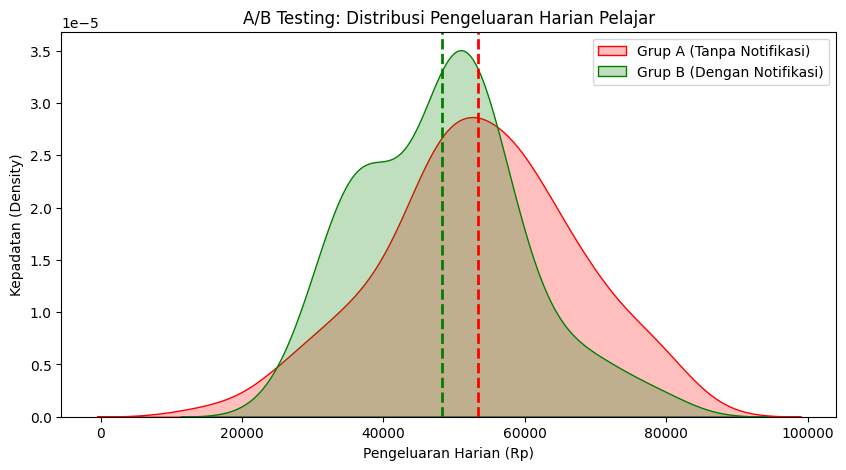

Rata-rata Pengeluaran Grup A : Rp 53,442.30
Rata-rata Pengeluaran Grup B : Rp 48,267.66
T-Statistic: 2.9085
P-Value    : 0.0020

KESIMPULAN: Tolak H0.
Fitur 'Notifikasi Batas Harian' TERBUKTI SECARA STATISTIK efektif menurunkan pengeluaran pelajar!


In [48]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat data buatan untuk keperluan pengujian
# Menentukan 'seed' acak agar data acak yang dihasilkan selalu sama setiap kali kode dijalankan
np.random.seed(42)

# Membuat data pengeluaran harian untuk Grup A (Kelompok Kontrol: Tanpa Notifikasi)
# Menggunakan distribusi normal dengan rata-rata (loc) Rp55.000, standar deviasi (scale) Rp15.000, sebanyak 100 pelajar (size)
grup_a = np.random.normal(loc=55000, scale=15000, size=100)

# Membuat data pengeluaran harian untuk Grup B (Kelompok Varian: Dengan Notifikasi)
# Menggunakan distribusi normal dengan rata-rata (loc) Rp48.000, standar deviasi (scale) Rp12.000, sebanyak 100 pelajar (size)
grup_b = np.random.normal(loc=48000, scale=12000, size=100)


# Membuat grafik untuk melihat persebaran data
plt.figure(figsize=(10, 5))

# Membuat kurva kepadatan (KDE Plot) untuk Grup A dengan warna merah dan area bawahnya diisi warna
sns.kdeplot(grup_a, label='Grup A (Tanpa Notifikasi)', fill=True, color='red')

# Membuat kurva kepadatan (KDE Plot) untuk Grup B dengan warna hijau dan area bawahnya diisi warna
sns.kdeplot(grup_b, label='Grup B (Dengan Notifikasi)', fill=True, color='green')

plt.axvline(grup_a.mean(), color='red', linestyle='dashed', linewidth=2)
plt.axvline(grup_b.mean(), color='green', linestyle='dashed', linewidth=2)
plt.title("A/B Testing: Distribusi Pengeluaran Harian Pelajar")
plt.xlabel("Pengeluaran Harian (Rp)")
plt.ylabel("Kepadatan (Density)")
plt.legend()
plt.show()

# Membuktikan apakah perbedaan kedua grup valid secara ilmiah
'''
Hipotesis Eksperimen:
H0 (Hipotesis Nol)      : Tidak ada perbedaan pengeluaran antara Grup A dan Grup B (fitur tidak ngefek).
H1 (Hipotesis Alternatif): Pengeluaran Grup A lebih besar daripada Grup B (fitur notifikasi berhasil bikin hemat).
'''

t_stat, p_value = stats.ttest_ind(grup_a, grup_b, alternative='greater')

print(f"Rata-rata Pengeluaran Grup A : Rp {grup_a.mean():,.2f}")
print(f"Rata-rata Pengeluaran Grup B : Rp {grup_b.mean():,.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value    : {p_value:.4f}")


# Mengambil keputusan bisnis berdasarkan angka statistik
# Menentukan batas toleransi kesalahan / tingkat signifikansi
alpha = 0.05

# Logika Pengambilan Keputusan:
# Jika P-Value lebih kecil dari Alpha, artinya peluang "kebetulan" sangat kecil, sehingga hasil dianggap signifikan.
if p_value < alpha:
    print("\nKESIMPULAN: Tolak H0.")
    print("Fitur 'Notifikasi Batas Harian' TERBUKTI SECARA STATISTIK efektif menurunkan pengeluaran pelajar!")
else:
    # Jika P-Value lebih besar atau sama dengan Alpha, artinya perbedaan tidak meyakinkan (bisa jadi cuma kebetulan)
    print("\nKESIMPULAN: Gagal Tolak H0.")
    print("Fitur tidak memberikan perbedaan signifikan. Perlu evaluasi ulang UI/UX notifikasi.")